In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt
import pandas as pd
import polars as pl

In [ ]:
df: pd.DataFrame = pl.read_excel("student_performance/student_performance.xlsx").to_pandas()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          714 non-null    int64  
 1   school      714 non-null    str    
 2   sex         714 non-null    str    
 3   age         710 non-null    float64
 4   address     712 non-null    str    
 5   famsize     709 non-null    str    
 6   Pstatus     707 non-null    str    
 7   Medu        709 non-null    float64
 8   Fedu        708 non-null    float64
 9   Mjob        713 non-null    str    
 10  Fjob        711 non-null    str    
 11  reason      710 non-null    str    
 12  guardian    711 non-null    str    
 13  traveltime  712 non-null    float64
 14  studytime   710 non-null    float64
 15  failures    711 non-null    float64
 16  schoolsup   712 non-null    str    
 17  famsup      711 non-null    str    
 18  paid        710 non-null    str    
 19  activities  707 non-null    str    
 20 

In [5]:
# Get numeric columns with missing values
columns = df.select_dtypes(include=[np.number]).isnull().sum().where(lambda x: x > 0).dropna().index.tolist()
print("Numeric columns with missing values:", columns)

for col in columns:
    df[col] = df[col].fillna(df[col].median())

# Get categorical columns with missing values
cat_columns = df.select_dtypes(include=['str']).isnull().sum().where(lambda x: x > 0).dropna().index.tolist()
for col in cat_columns:
    df[col] = df[col].fillna(df[col].mode()[0])


Numeric columns with missing values: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'goout', 'Dalc', 'Walc', 'health', 'absences']


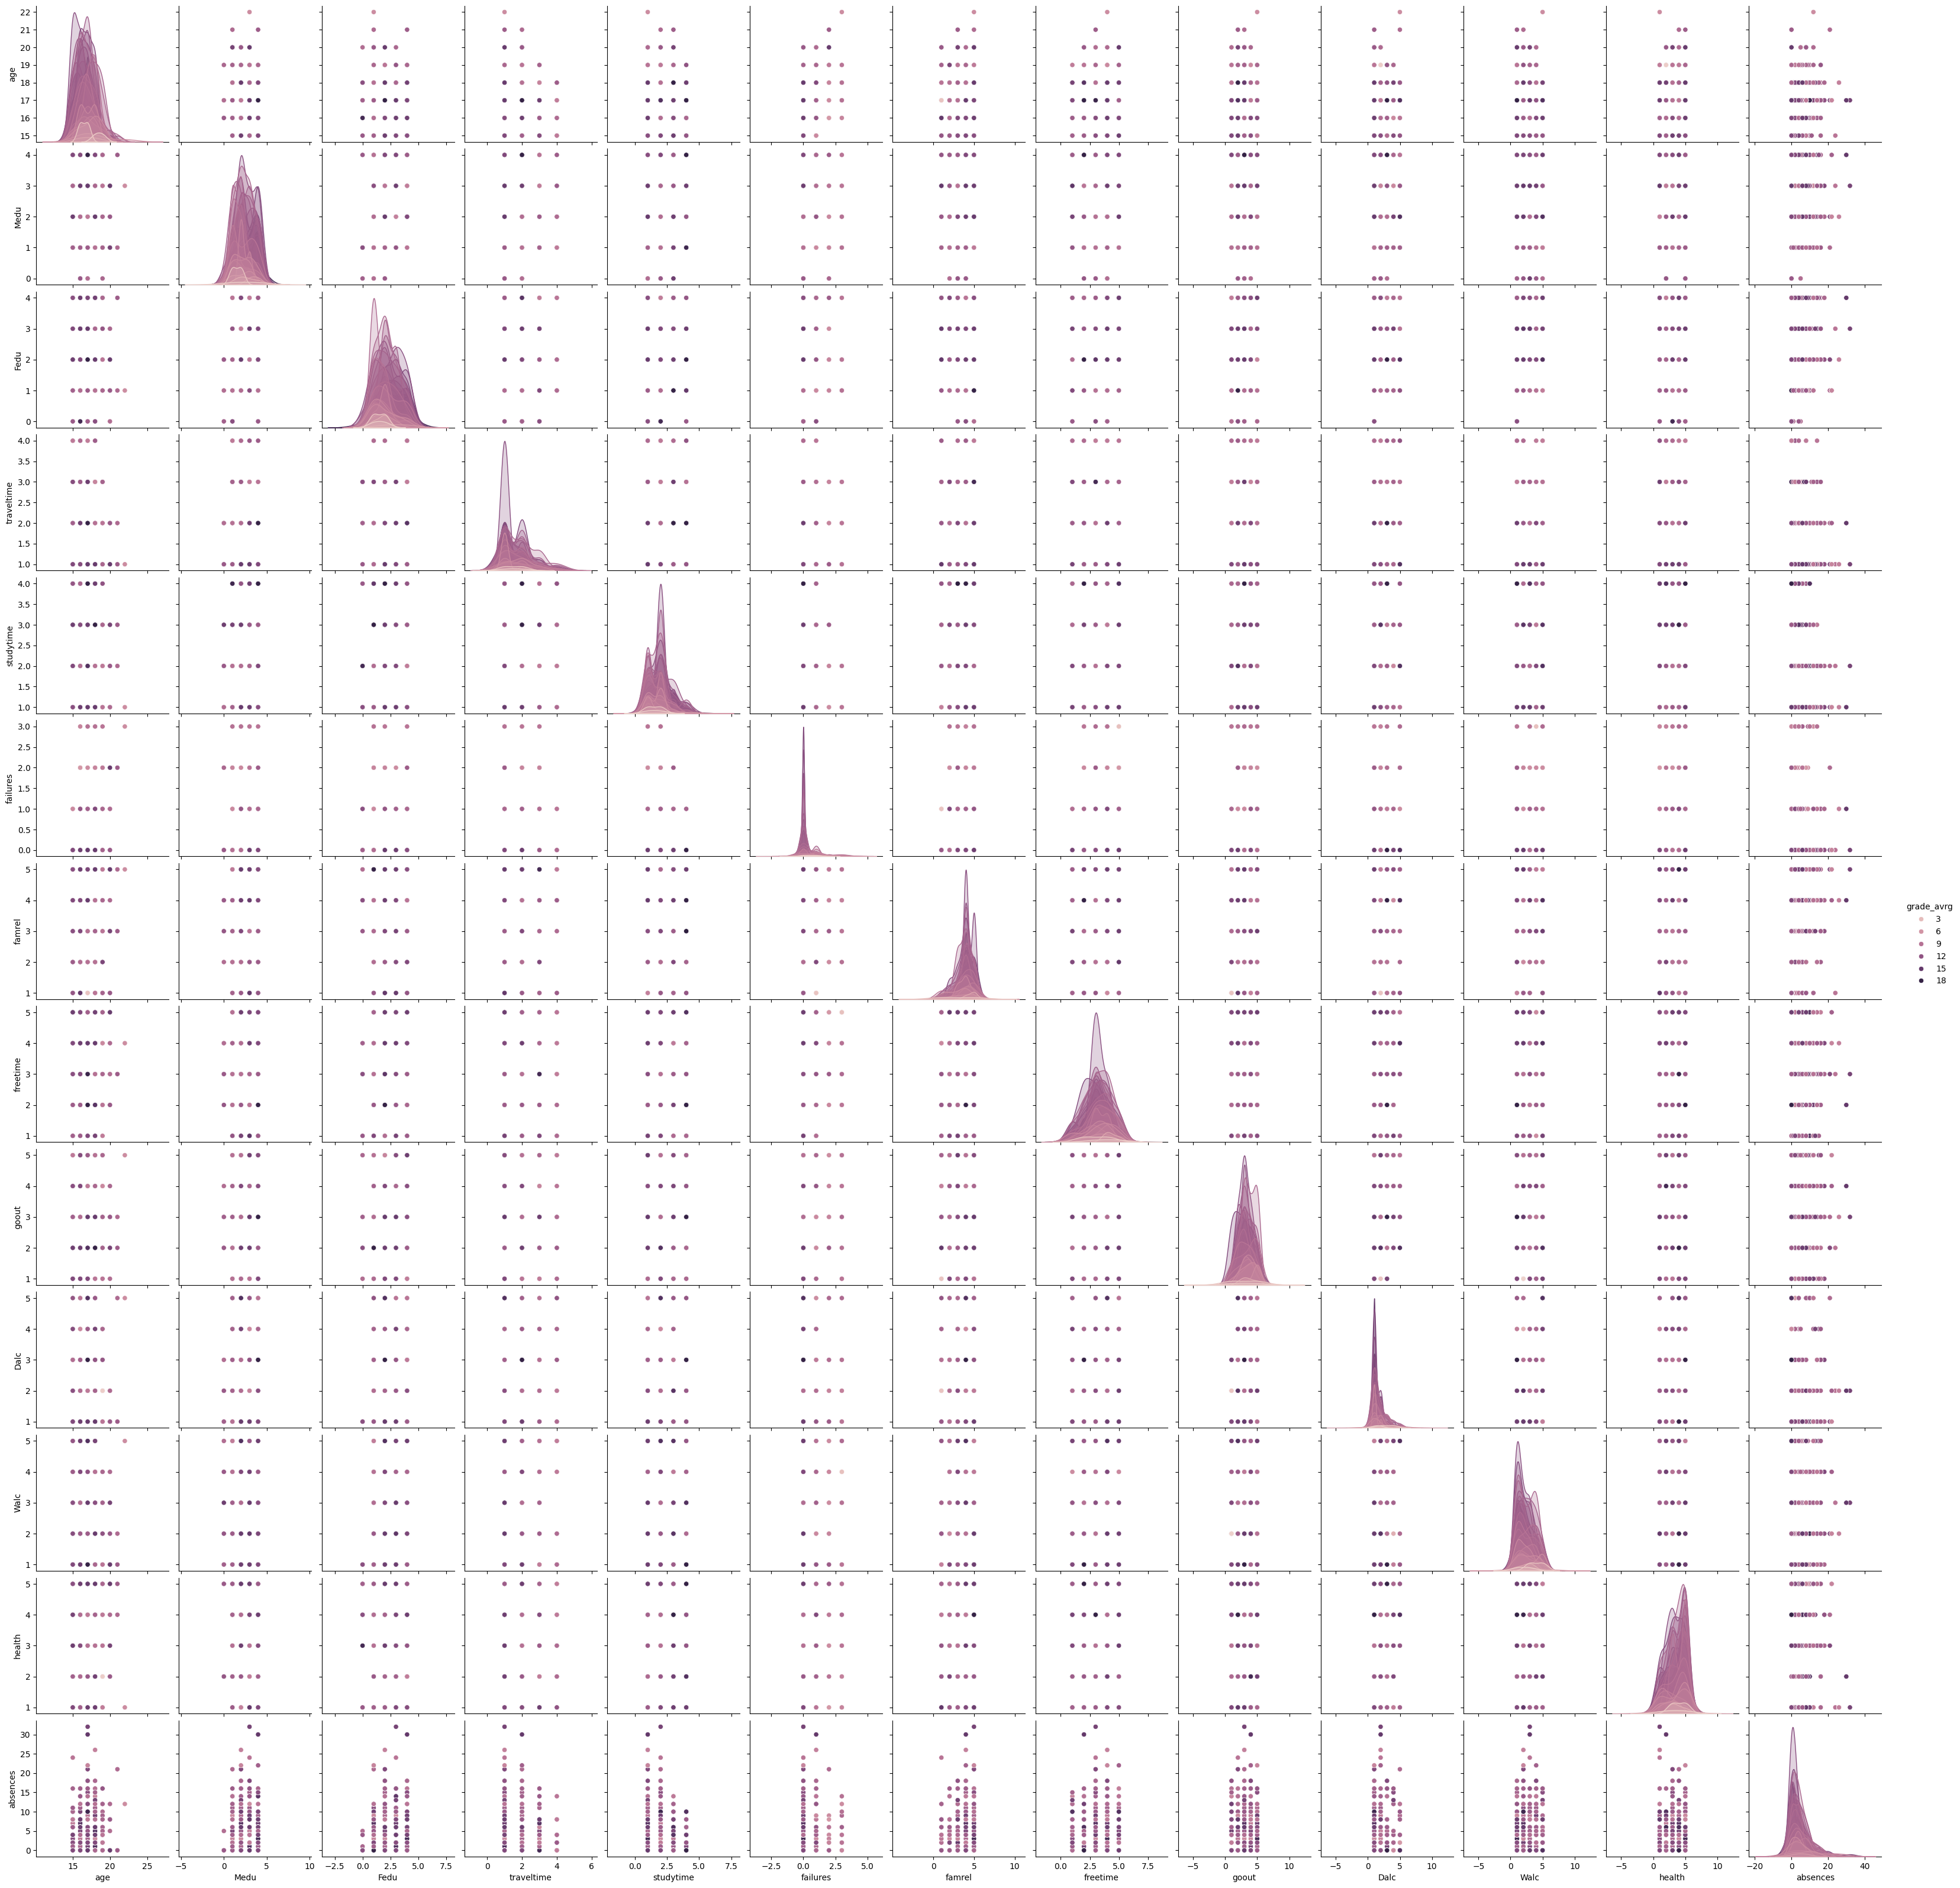

In [ ]:
df["grade_avrg"] = df[["G1", "G2", "G3"]].mean(axis=1)

# sns.pairplot(df.drop(columns=["G1", "G2", "G3", "id"]), hue="grade_avrg")

In [12]:
# Use a scatter plot for grade_avrg vs studytime to allow rectangular (x and y) selection
brush = alt.selection_interval(encodings=['x', 'y'])

base = alt.Chart(df).properties(
    width=300,
    height=250
)

# 1. grade_avrg vs studytime (scatter plot, brush enabled)
scatter1 = base.mark_circle(size=60).encode(
    x=alt.X('studytime:O', title='Study Time'),
    y=alt.Y('grade_avrg:Q', title='Average Grade'),
    color=alt.Color('sex:N', title='Sex'),
    tooltip=['studytime', 'grade_avrg', 'sex']
).add_params(brush)

# 2. absences vs grade_avrg (scatter plot) - FILTERED by the brush
scatter2 = base.mark_circle(size=60).transform_filter(
    brush
).encode(
    x=alt.X('absences:Q', title='Absences'),
    y=alt.Y('grade_avrg:Q', title='Average Grade'),
    color=alt.Color('sex:N', title='Sex'),
    tooltip=['absences', 'grade_avrg', 'sex']
)

# 3. traveltime (% bar plot) - FILTERED by the brush
# numeric: 
# 1 - <15 min., 
# 2 - 15 to 30 min., 
# 3 - 30 min. to 1 hour, 
# or 4 - >1 hour
bar_travel = base.transform_filter(
    brush
).mark_bar().encode(
    x=alt.X('traveltime:O', title='Travel Time'),
    y=alt.Y('count():Q', stack='normalize', title='Percentage'),
    color=alt.Color('sex:N', title='Sex')
)


# 4. Heatmap for parental education - FILTERED by the brush
# Add labels:
# numeric: 0 - none,  
# 1 - primary education (4th grade), 
# 2 – 5th to 9th grade, 
# 3 – secondary education or 
# 4 – higher education
heatmap = base.transform_filter(
    brush
).mark_rect().encode(
    x=alt.X('Medu:O', title='Mother Education'),
    y=alt.Y('Fedu:O', title='Father Education'),
    color=alt.Color('count():Q', scale=alt.Scale(scheme='viridis')), 
)

# 5. Social Life (Dalc, Walc, freetime, goout) - Grouped by Sex and FILTERED
social_plot = alt.Chart(df).transform_filter(
    brush
).transform_fold(
    ['Dalc', 'Walc', 'freetime', 'goout'],
    as_=['Metric', 'Score']
).mark_bar().encode(
    x=alt.X('Metric:N', title='Social Metric'),
    y=alt.Y('mean(Score):Q', title='Average Score'),
    xOffset='sex:N',
    color=alt.Color('sex:N', title='Sex')
).properties(
    width=300,
    height=250,
    title='Social Life Averages'
)

# Combine the charts into a dashboard array
#dashboard = (scatter1 | scatter2) & (bar_travel | heatmap) & social_plot
dashboard = (scatter1 | scatter2) & (heatmap | social_plot)

dashboard

alt.VConcatChart(...)